<a href="https://colab.research.google.com/github/cmburban/MAT-422/blob/main/MAT422_Section_1_3_QR_Least_Squares_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 1.3: QR Decomposition, Least Squares, and Linear Regression

Topics: QR decomposition, least-squares problems, linear regression

In [1]:
import numpy as np

## 1.3.1 QR Decomposition

QR decomposition factors a matrix A into two matrices, Q and R, where Q has orthonormal columns and R is an upper triangular matrix. This decomposition is useful for solving linear algebra problems and least-squares problems.

In [2]:
A = np.array([
    [1, 1],
    [1, 2],
    [1, 3]
], dtype=float)

Q, R = np.linalg.qr(A)

print("A =")
print(A)

print("\nQ =")
print(Q)

print("\nR =")
print(R)

A =
[[1. 1.]
 [1. 2.]
 [1. 3.]]

Q =
[[-5.77350269e-01  7.07106781e-01]
 [-5.77350269e-01  5.55111512e-17]
 [-5.77350269e-01 -7.07106781e-01]]

R =
[[-1.73205081 -3.46410162]
 [ 0.         -1.41421356]]


### Verifying Q

The columns of Q should be orthonormal. I can verify this by calculating Q.T @ Q. The result should be the identity matrix.

In [3]:
QTQ = Q.T @ Q

print("Q.T @ Q =")
print(QTQ)

Q.T @ Q =
[[ 1.00000000e+00 -1.16219581e-16]
 [-1.16219581e-16  1.00000000e+00]]


The result is approximately the identity matrix, which confirms that the columns of Q are orthonormal.

### Verifying the QR Decomposition

A should be equal to Q @ R. I will multiply Q and R together and compare the result with the original matrix A.

In [4]:
A_reconstructed = Q @ R

print("Q @ R =")
print(A_reconstructed)

print("\nDifference between A and Q @ R:")
print(A - A_reconstructed)

Q @ R =
[[1. 1.]
 [1. 2.]
 [1. 3.]]

Difference between A and Q @ R:
[[1.11022302e-16 2.22044605e-16]
 [1.11022302e-16 2.22044605e-16]
 [1.11022302e-16 4.44089210e-16]]


The product Q @ R reconstructs the original matrix A, with only tiny floating-point differences. This confirms that the QR decomposition was calculated correctly.

## 1.3.2 Least-Squares Problems

A least-squares problem finds the vector x that gives the best approximate solution to A x = b when an exact solution may not exist. The goal is to minimize the difference between A x and b.

In [5]:
b = np.array([2, 3, 5], dtype=float)

print("A =")
print(A)

print("\nb =")
print(b)

A =
[[1. 1.]
 [1. 2.]
 [1. 3.]]

b =
[2. 3. 5.]


### Finding the Least-Squares Solution

I will use NumPy's least-squares function to find the values of x that best approximate the system A x = b.

In [6]:
x, residuals, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)

print("Least-squares solution x:")
print(x)

print("\nResiduals:")
print(residuals)

Least-squares solution x:
[0.33333333 1.5       ]

Residuals:
[0.16666667]


### Predicted Values

I can multiply A by the least-squares solution to see the values predicted by the model.

In [7]:
b_predicted = A @ x

print("Predicted values:")
print(b_predicted)

print("\nOriginal values:")
print(b)

print("\nResiduals:")
print(b - b_predicted)

Predicted values:
[1.83333333 3.33333333 4.83333333]

Original values:
[2. 3. 5.]

Residuals:
[ 0.16666667 -0.33333333  0.16666667]


The predicted values are close to the original values, but they are not exactly the same. This is expected because the system is overdetermined, so the least-squares solution minimizes the overall error rather than matching every value exactly.

### Residual Norm

The residual vector shows the difference between the original values and the predicted values. I can use the Euclidean norm of the residual to measure the overall error of the least-squares solution.

In [8]:
residual = b - b_predicted
residual_norm = np.linalg.norm(residual)

print("Residual vector:")
print(residual)

print("\nResidual norm:")
print(residual_norm)

Residual vector:
[ 0.16666667 -0.33333333  0.16666667]

Residual norm:
0.4082482904638633


The residual norm is approximately 0.408. A smaller residual norm means that the predictions are closer to the original values, so this gives a measure of how well the least-squares solution fits the data.

### Solving Least Squares Using QR Decomposition

QR decomposition can also be used to solve a least-squares problem. Since A = QR, the least-squares solution can be found by solving R x = Q.T @ b.

In [15]:
Q, R = np.linalg.qr(A)

x_qr = np.linalg.solve(R, Q.T @ b)

print("Least-squares solution using QR:")
print(x_qr)

print("\nSolution from np.linalg.lstsq:")
print(x)

Least-squares solution using QR:
[0.33333333 1.5       ]

Solution from np.linalg.lstsq:
[0.33333333 1.5       ]


The two methods produce the same least-squares solution up to small numerical differences. This shows how QR decomposition can be used as an alternative method for solving least-squares problems.

## 1.3.3 Linear Regression

Linear regression models the relationship between an input variable and an output variable using a line. The line is chosen to minimize the sum of the squared differences between the observed values and the predicted values. I will use a small dataset to find and visualize a best-fit line.

In [10]:
import matplotlib.pyplot as plt

hours = np.array([1, 2, 3, 4, 5], dtype=float)
scores = np.array([62, 67, 71, 78, 82], dtype=float)

print("Hours studied:", hours)
print("Quiz scores:", scores)

Hours studied: [1. 2. 3. 4. 5.]
Quiz scores: [62. 67. 71. 78. 82.]


### Creating the Design Matrix

To use least squares for linear regression, I need a design matrix with a column of ones for the intercept and a column containing the input values.

In [11]:
X = np.column_stack((np.ones(len(hours)), hours))

print("Design matrix X:")
print(X)

Design matrix X:
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]


### Finding the Regression Line

I will use the least-squares method to find the intercept and slope of the regression line. The resulting model will have the form y = b0 + b1x.

In [12]:
coefficients, residuals, rank, singular_values = np.linalg.lstsq(X, scores, rcond=None)

intercept = coefficients[0]
slope = coefficients[1]

print("Intercept:", intercept)
print("Slope:", slope)

print("\nRegression equation:")
print(f"y = {intercept:.2f} + {slope:.2f}x")

Intercept: 56.69999999999999
Slope: 5.099999999999995

Regression equation:
y = 56.70 + 5.10x


### Predictions

I can use the regression equation to calculate the predicted quiz score for each number of study hours.

In [13]:
predicted_scores = X @ coefficients

print("Actual scores:")
print(scores)

print("\nPredicted scores:")
print(predicted_scores)

print("\nResiduals:")
print(scores - predicted_scores)

Actual scores:
[62. 67. 71. 78. 82.]

Predicted scores:
[61.8 66.9 72.  77.1 82.2]

Residuals:
[ 0.2  0.1 -1.   0.9 -0.2]


The predicted scores are generally close to the actual scores. The differences between the actual and predicted values are the residuals. The regression line provides a simple way to describe the overall relationship between study time and quiz performance.

### Visualizing the Regression

The scatter plot shows the original data points, while the line shows the least-squares regression model.

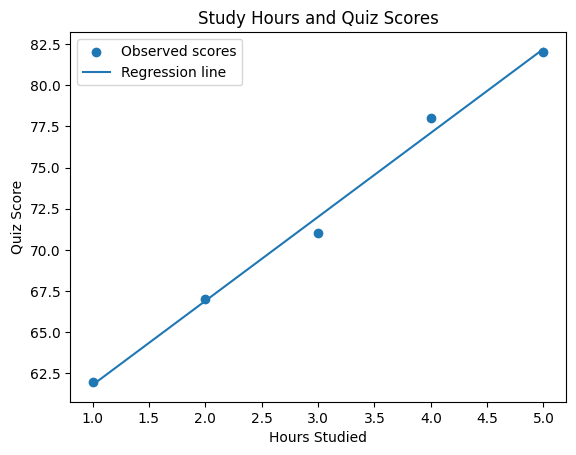

In [16]:
plt.scatter(hours, scores, label="Observed scores")
plt.plot(hours, predicted_scores, label="Regression line")

plt.xlabel("Hours Studied")
plt.ylabel("Quiz Score")
plt.title("Study Hours and Quiz Scores")
plt.legend()
plt.show()

The plot shows a positive relationship between study hours and quiz scores. The regression line follows the overall upward trend in the data. Although the line does not pass through every point, it represents the best linear fit according to the least-squares method.

## End of Notebook Reflection

In this notebook, I showed examples of QR decomposition, least-squares problems, and linear regression using NumPy. I learned QR decomposition can break a matrix into an orthonormal matrix Q and an upper triangular matrix R. Q.T @ Q and Q @ R verified this. I also used least squares to find the best approximate solution to an overdetermined system. The residuals and residual norm helped me measure how close the solution matched the original data. For the linear regression example, I used study hours and quiz scores to show a possible real-world application. The regression line showed a positive relationship between the number of hours studied and quiz scores. One thing I found interesting was comparing the least-squares solution from NumPy with the solution from QR decomposition. It showed me that both methods did the same thing, as the results were almost the exact same.

## Reference

[Mathematical Methods in Data Science – Elsevier (2023)](https://doi.org/10.1016/B978-0-44-318679-0.00007-7)

[QuantEcon – Linear Algebra](https://python.quantecon.org/linear_algebra.html)

[NumPy – Linear Algebra](https://numpy.org/doc/stable/reference/routines.linalg.html)

[NumPy – Least Squares](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)

[OpenAI – ChatGPT (2026)](https://chatgpt.com/)

## Checklist

I explained each concept in words before or after the code. [DONE]

I verified important claims numerically, such as dot products, norms, identities, or residuals. [DONE]

I changed or extended at least one example so the notebook reflects my own work. [DONE]

I ran the notebook from top to bottom without errors. [DONE]

I saved the notebook from Google Colab directly to GitHub, following the course instructions. [DONE]